# **Python Project 2**

Tasks


*   Analyze diabetes data by first picking a group as the initial comparison point
*   Pick a feature/measure/indicator
* Compare the group to any other group
* Finish with a brief conclusion



Comparison analysis should include:


*   Descriptive statistics
*   Cleaning tasks (one or more)
* Visualizations (one or more)



In [1]:
#Start the session by importing packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
#Then import the data

health_df = pd.read_csv("https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv")

In [3]:
health_df.shape

(101766, 50)

In [4]:
health_df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [5]:
health_df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [9]:
health_df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


In [8]:
#What kind of data types are in the dataset?

print(health_df.dtypes)

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [6]:
#Determine if there are any null values

health_df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [23]:
#Are all the values in "weight" column question marks?
  #Answer: All but 10
health_df["weight"].describe()

,weight
count,101766
unique,10
top,?
freq,98569


In [27]:
#Replace ? values with NaN

health_df["weight"] = health_df["weight"].replace("?", np.nan)
health_df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [24]:
#How many are unique patients?

health_df.nunique()

,0
encounter_id,101766
patient_nbr,71518
race,6
gender,3
age,10
weight,10
admission_type_id,8
discharge_disposition_id,26
admission_source_id,17
time_in_hospital,14


Compare women with multiple diagnoses

In [31]:
health_diag = health_df[['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'time_in_hospital', 'payer_code', 'medical_specialty','num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'diabetesMed', 'readmitted']]
health_diag.head()

,encounter_id,patient_nbr,race,gender,age,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,No,NO
1,149190,55629189,Caucasian,Female,[10-20),3,?,?,59,0,18,0,0,0,276,250.01,255,9,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),2,?,?,11,5,13,2,0,1,648,250,V27,6,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),2,?,?,44,1,16,0,0,0,8,250.43,403,7,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,?,?,51,0,8,0,0,0,197,157,250,5,Yes,NO


In [32]:
#Change ? values to NaN

health_diag = health_diag.replace("?", np.nan)

In [35]:
#Filter by female patients

health_fdiag = health_diag[health_diag["gender"] == "Female"]
health_fdiag.head()

,encounter_id,patient_nbr,race,gender,age,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,No,NO
1,149190,55629189,Caucasian,Female,[10-20),3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,Yes,NO
8,12522,48330783,Caucasian,Female,[80-90),13,NaN,NaN,68,2,28,0,0,0,398,427,38,8,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),12,NaN,InternalMedicine,33,3,18,0,0,0,434,198,486,8,Yes,NO


In [68]:
health_fdiag["medical_specialty"].value_counts()

,count
medical_specialty,
InternalMedicine,8347
Family/GeneralPractice,4192
Emergency/Trauma,4082
Cardiology,2376
Surgery-General,1627
...,...
Pediatrics-AllergyandImmunology,1
Proctology,1
Speech,1


<Axes: xlabel='age'>

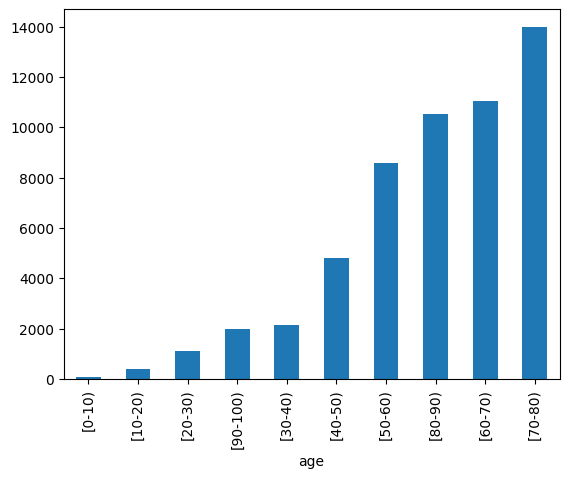

In [36]:
health_fdiag.groupby(["age"])["gender"].count().sort_values(ascending=True).plot(kind='bar')

In [44]:
health_fdiag.groupby(["diag_1"])["gender"].describe()

,count,unique,top,freq
diag_1,,,,
11,2,1,Female,2
110,1,1,Female,1
112,44,1,Female,44
114,1,1,Female,1
115,2,1,Female,2
...,...,...,...,...
V57,682,1,Female,682
V58,91,1,Female,91
V63,3,1,Female,3


In [45]:
health_fdiag.groupby(["diag_2"])["gender"].describe()

,count,unique,top,freq
diag_2,,,,
11,1,1,Female,1
110,4,1,Female,4
111,1,1,Female,1
112,139,1,Female,139
115,1,1,Female,1
...,...,...,...,...
V69,1,1,Female,1
V70,3,1,Female,3
V72,9,1,Female,9


In [46]:
health_fdiag.groupby(["diag_3"])["gender"].describe()

,count,unique,top,freq
diag_3,,,,
110,9,1,Female,9
112,139,1,Female,139
115,1,1,Female,1
117,3,1,Female,3
122,1,1,Female,1
...,...,...,...,...
V66,11,1,Female,11
V70,1,1,Female,1
V72,2,1,Female,2


In [48]:
health_fdiag["diag_1"].value_counts(ascending=False)

,count
diag_1,
428,3628
414,2739
786,2320
486,1837
410,1605
...,...
V51,1
384,1
361,1


In [61]:
health_fdiag["diag_2"].value_counts(ascending=False)

,count
diag_2,
276,3883
428,3715
250,3315
427,2509
599,2358
...,...
893,1
141,1
703,1


In [63]:
health_fdiag["diag_3"].value_counts(ascending=False)

,count
diag_3,
250,6355
401,4673
276,2927
428,2559
427,1919
...,...
E854,1
E916,1
750,1


Conclusion:
* Older populations are more frequently patients.
* The most frequent diagnosis for female patients is heart failure (ICD 428).